In [4]:
import sys
print(sys.executable)

c:\Mitali - Resume\Quant Risk Modelling Techniques\venv\Scripts\python.exe


In [40]:
!pip install matplotlib

                                              0.0/9.3 MB ? eta -:--:--
                                              0.1/9.3 MB 3.3 MB/s eta 0:00:03
     -                                        0.3/9.3 MB 2.6 MB/s eta 0:00:04
     -                                        0.4/9.3 MB 2.5 MB/s eta 0:00:04
     --                                       0.6/9.3 MB 2.9 MB/s eta 0:00:04
     ---                                      0.7/9.3 MB 2.8 MB/s eta 0:00:04
     ---                                      0.9/9.3 MB 3.0 MB/s eta 0:00:03
     ----                                     1.1/9.3 MB 3.1 MB/s eta 0:00:03
     -----                                    1.2/9.3 MB 3.2 MB/s eta 0:00:03
     -----                                    1.4/9.3 MB 3.2 MB/s eta 0:00:03
     ------                                   1.6/9.3 MB 3.2 MB/s eta 0:00:03
     -------                                  1.8/9.3 MB 3.3 MB/s eta 0:00:03
     --------                                 2.0/9.3 MB 3.3 MB/s eta 0


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [6]:
reliance = yf.download("RELIANCE.NS","2025-01-01","2026-01-01")

[*********************100%***********************]  1 of 1 completed


In [7]:
reliance

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2025-01-01,1210.793579,1215.800389,1201.226179,1204.448352,5892590
2025-01-02,1231.167725,1233.794938,1209.554328,1210.793626,15486276
2025-01-03,1240.437622,1251.244320,1224.921594,1233.249697,15521102
2025-01-06,1207.571533,1251.194807,1204.597219,1243.213682,14816766
2025-01-07,1230.225708,1233.844481,1210.793549,1211.537128,10070505
...,...,...,...,...,...
2025-12-24,1551.028687,1568.448147,1546.449881,1565.461954,8815745
2025-12-26,1552.024048,1553.815812,1547.146696,1547.544758,2311495


In [8]:
adani = yf.download("ADANIENT.NS","2025-01-01","2026-01-01")

[*********************100%***********************]  1 of 1 completed


In [9]:
lt = yf.download("LT.NS","2025-01-01","2026-01-01")

[*********************100%***********************]  1 of 1 completed


In [10]:
data = pd.DataFrame(reliance["Close"])
data['ADANIENT.NS'] = adani["Close"]
data['LT.NS'] = lt["Close"]
data

Ticker,RELIANCE.NS,ADANIENT.NS,LT.NS
Date,,,
2025-01-01,1210.793579,2552.442871,3598.464355
2025-01-02,1231.167725,2595.252441,3643.598389
2025-01-03,1240.437622,2562.183838,3591.007080
2025-01-06,1207.571533,2472.118652,3535.374512
2025-01-07,1230.225708,2518.175049,3574.719971
...,...,...,...
2025-12-24,1551.028687,2221.706543,4014.390137
2025-12-26,1552.024048,2228.903320,4008.150879
2025-12-29,1538.486694,2202.215332,3999.634033


In [11]:
returns = (data / data.shift(1)) -1
returns

Ticker,RELIANCE.NS,ADANIENT.NS,LT.NS
Date,,,
2025-01-01,NaN,NaN,NaN
2025-01-02,0.016827,0.016772,0.012543
2025-01-03,0.007529,-0.012742,-0.014434
2025-01-06,-0.026496,-0.035152,-0.015492
2025-01-07,0.018760,0.018630,0.011129
...,...,...,...
2025-12-24,-0.007958,-0.011606,-0.001281
2025-12-26,0.000642,0.003239,-0.001554
2025-12-29,-0.008722,-0.011974,-0.002125


In [12]:
returns.drop(returns.index[0],inplace=True)

In [13]:
returns

Ticker,RELIANCE.NS,ADANIENT.NS,LT.NS
Date,,,
2025-01-02,0.016827,0.016772,0.012543
2025-01-03,0.007529,-0.012742,-0.014434
2025-01-06,-0.026496,-0.035152,-0.015492
2025-01-07,0.018760,0.018630,0.011129
2025-01-08,0.019866,-0.002103,-0.012887
...,...,...,...
2025-12-24,-0.007958,-0.011606,-0.001281
2025-12-26,0.000642,0.003239,-0.001554
2025-12-29,-0.008722,-0.011974,-0.002125


In [14]:
portfolio = pd.Series({"RELIANCE.NS":50000,"ADANIENT.NS":50000,"LT.NS":100000})
portfolio

RELIANCE.NS     50000
ADANIENT.NS     50000
LT.NS          100000
dtype: int64

In [15]:
pnl = returns * portfolio
pnl

Ticker,RELIANCE.NS,ADANIENT.NS,LT.NS
Date,,,
2025-01-02,841.355036,838.599970,1254.258171
2025-01-03,376.467693,-637.098014,-1443.389281
2025-01-06,-1324.777977,-1757.586326,-1549.219122
2025-01-07,938.005500,931.516706,1112.907808
2025-01-08,993.276549,-105.134110,-1288.664916
...,...,...,...
2025-12-24,-397.908956,-580.310478,-128.115617
2025-12-26,32.087135,161.965075,-155.422308
2025-12-29,-436.119322,-598.679809,-212.488151


In [16]:
pnl['Portfolio_pnl'] = pnl.sum(axis=1)
pnl

Ticker,RELIANCE.NS,ADANIENT.NS,LT.NS,Portfolio_pnl
Date,,,,
2025-01-02,841.355036,838.599970,1254.258171,2934.213177
2025-01-03,376.467693,-637.098014,-1443.389281,-1704.019602
2025-01-06,-1324.777977,-1757.586326,-1549.219122,-4631.583425
2025-01-07,938.005500,931.516706,1112.907808,2982.430015
2025-01-08,993.276549,-105.134110,-1288.664916,-400.522478
...,...,...,...,...
2025-12-24,-397.908956,-580.310478,-128.115617,-1106.335051
2025-12-26,32.087135,161.965075,-155.422308,38.629902
2025-12-29,-436.119322,-598.679809,-212.488151,-1247.287282


In [17]:
pnl_sorted = pnl.sort_values(by='Portfolio_pnl')
pnl_sorted

Ticker,RELIANCE.NS,ADANIENT.NS,LT.NS,Portfolio_pnl
Date,,,,
2025-04-07,-1618.657611,-2611.737674,-5878.565076,-10108.960360
2025-04-04,-1761.833196,-1579.353682,-4678.152442,-8019.339320
2025-02-03,-739.360430,-179.515694,-4591.735984,-5510.612108
2025-01-13,-82.535752,-3142.899222,-2031.871958,-5257.306932
2025-01-06,-1324.777977,-1757.586326,-1549.219122,-4631.583425
...,...,...,...,...
2025-01-31,480.824738,781.317379,4280.969855,5543.111972
2025-03-19,334.990895,1463.800793,4603.830145,6402.621834
2025-02-04,1577.167605,876.492806,4558.860909,7012.521320


In [18]:
Confidence_interval = 99
VaR_99 = np.percentile(pnl_sorted['Portfolio_pnl'],100-Confidence_interval)
print("99% C.I. Value at Risk for Portfolio is:",-VaR_99)

99% C.I. Value at Risk for Portfolio is: 5391.558674985572


In [27]:
worst_loss_count = np.ceil(pnl_sorted['Portfolio_pnl'].shape[0] * ((100-Confidence_interval)/100))
ESF_99 = (pnl_sorted['Portfolio_pnl'].iloc[:int(worst_loss_count)].sum())/worst_loss_count
print("99% C.I. Expected Shortfall VaR for Portfolio is:",-ESF_99)

99% C.I. Expected Shortfall VaR for Portfolio is: 7879.6372623762045


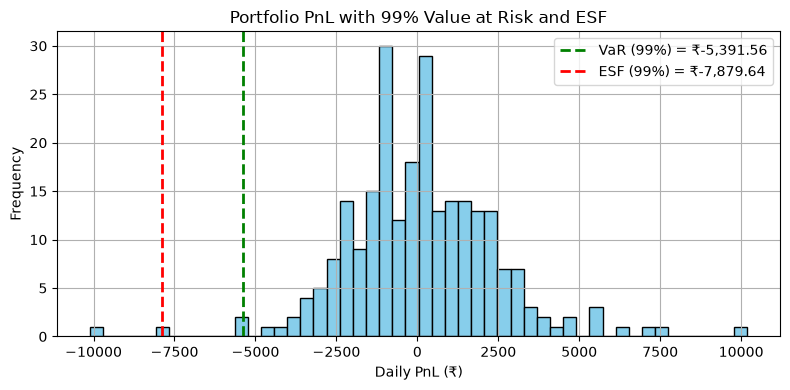

In [46]:
plt.figure(figsize=(8,4))
plt.hist(pnl_sorted['Portfolio_pnl'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(VaR_99, color='green', linestyle='--', linewidth=2, 
            label=f'VaR (99%) = ₹{VaR_99:,.2f}')
plt.axvline(ESF_99, color='red', linestyle='--', linewidth=2, 
            label=f'ESF (99%) = ₹{ESF_99:,.2f}')
plt.title('Portfolio PnL with 99% Value at Risk and ESF')
plt.xlabel('Daily PnL (₹)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
Confidence_intervals = [90,95,99]
VaR = {}
ESF = {}
for i in Confidence_intervals:
    VaR[i] = -np.percentile(pnl_sorted['Portfolio_pnl'],100-i)
    worst_loss_count = np.ceil(pnl_sorted['Portfolio_pnl'].shape[0] * ((100-i)/100))
    ESF[i] = -(pnl_sorted['Portfolio_pnl'].iloc[:int(worst_loss_count)].sum())/worst_loss_count

In [37]:
VaR

{90: np.float64(2379.298223949438),
 95: np.float64(3154.7405097301707),
 99: np.float64(5391.558674985572)}

In [38]:
ESF

{90: np.float64(3816.0583737081197),
 95: np.float64(4789.167629914345),
 99: np.float64(7879.6372623762045)}

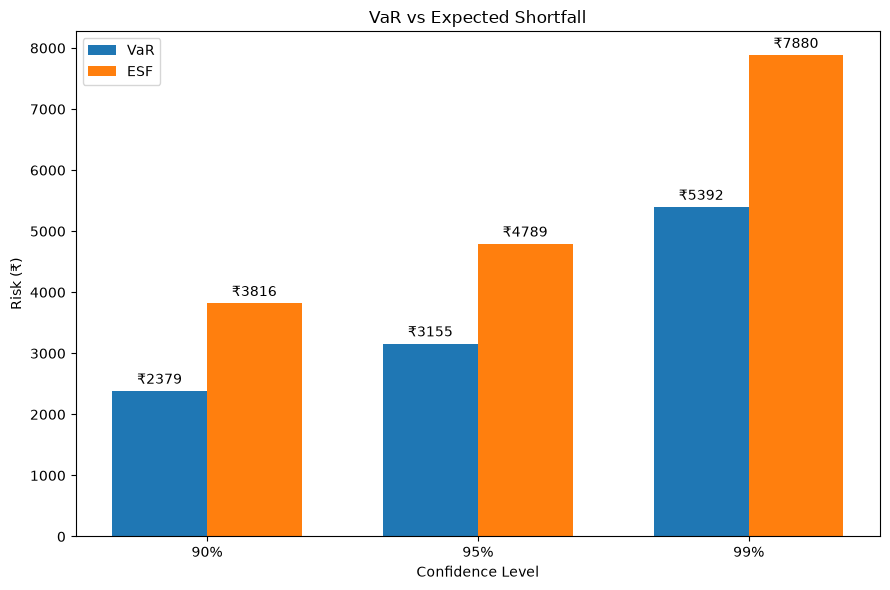

In [58]:
x = np.arange(len(Confidence_intervals))
width = 0.35

plt.figure(figsize=(9, 6))

bars1 = plt.bar(x - width/2, VaR.values(), width, label="VaR")
bars2 = plt.bar(x + width/2, ESF.values(), width, label="ESF")

plt.xticks(x, ["90%", "95%", "99%"])
plt.xlabel("Confidence Level")
plt.ylabel("Risk (₹)")
plt.title("VaR vs Expected Shortfall")
plt.legend()

plt.bar_label(bars1, fmt="₹%.0f", padding=3)
plt.bar_label(bars2, fmt="₹%.0f", padding=3)

plt.tight_layout()
plt.show()